Hello! This is a notebook
Used for Visualizing Images, Class Distribution and Sample Boxes.

Imports

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
from pathlib import Path

Count the # of images in each dataset

In [3]:
train_1 = Path("../data/raw/egohands/train")
test_1 = Path("../data/raw/egohands/test")
val_1 = Path("../data/raw/egohands/valid")
train_2 = Path("../data/raw/digits/train")
test_2 = Path("../data/raw/digits/test")
val_2 = Path("../data/raw/digits/valid")

egohands_train = list(train_1.glob("*.jpg"))
egohands_test = list(test_1.glob("*.jpg"))
egohands_val = list(val_1.glob("*.jpg"))

print("HAND DETECTION |")
print(f"There are {len(egohands_train)} images in the hand detection TRAINING dataset")
print(f"There are {len(egohands_test)} images in the hand detection TESTING dataset")
print(f"There are {len(egohands_val)} images in the hand detection VALIDATION dataset")

digits_train = list(train_2.glob("*.png"))
digits_test = list(test_2.glob("*.png"))
digits_val = list(val_2.glob("*.png"))

print("DIGIT CLASSIFICATION |")
print(f"There are {len(digits_train)} images in the digit classification TRAINING dataset")
print(f"There are {len(digits_test)} images in the digit classification TESTING dataset")
print(f"There are {len(digits_val)} images in the digit classification VALIDATION dataset")

HAND DETECTION |
There are 11247 images in the hand detection TRAINING dataset
There are 480 images in the hand detection TESTING dataset
There are 480 images in the hand detection VALIDATION dataset
DIGIT CLASSIFICATION |
There are 16200 images in the digit classification TRAINING dataset
There are 3600 images in the digit classification TESTING dataset
There are 1800 images in the digit classification VALIDATION dataset


Display a few sample images

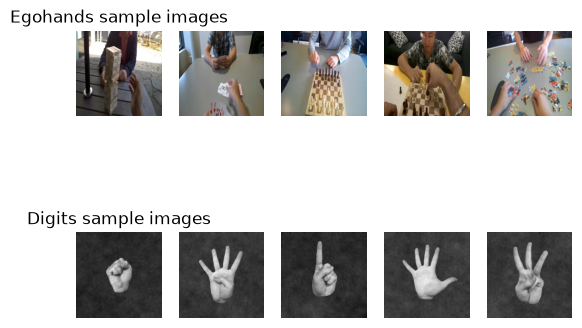

In [4]:
num_samples = 5

fig, axes = plt.subplots(2,num_samples)
axes[0,0].set_title("Egohands sample images")
axes[1, 0].set_title("Digits sample images")
for i in range(num_samples): #Load egohands images
    num = random.randint(0, len(egohands_test)-1)
    img = cv2.imread(str(egohands_test[num]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[0, i].imshow(img)
    axes[0,i].axis("off")


for i in range(num_samples): #Load digits images
    num = random.randint(0, len(digits_test)-1)
    img = cv2.imread(str(digits_test[num]))
    axes[1, i].imshow(img)
    axes[1,i].axis("off")



Look at sample egohands images with bounding boxes added

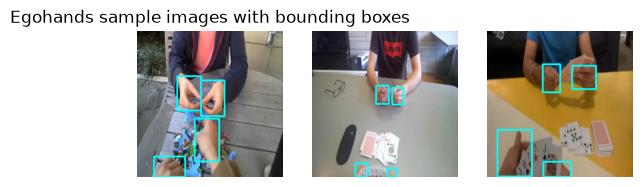

In [5]:
num_samples = 3

fig, axes = plt.subplots(1,num_samples)
axes[0].set_title("Egohands sample images with bounding boxes")
for i in range(num_samples):
    num = random.randint(0, len(egohands_test)-1)
    img = cv2.imread(str(egohands_test[num]))
    H = img.shape[0] # Height and width of the image in pixels
    W = img.shape[1]
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    txtPath = egohands_test[num].with_suffix(".txt")

    with open(txtPath, "r") as f:
        lines = f.readlines()
        for line in lines:
            values = line.strip().split()

            class_id = int(values[0])
            # YOLO format data
            x_center = float(values[1]) # Scale 
            y_center = float(values[2])
            box_w =  float(values[3])
            box_h = float(values[4])

            x_center_pixels = x_center*W
            y_center_pixels = y_center*H
            box_w_pixels = box_w*W
            box_h_pixels = box_h*H

            x1 = round(x_center_pixels-box_w_pixels/2)
            x2 = round(x_center_pixels+box_w_pixels/2)
            y1 = round(y_center_pixels-box_h_pixels/2)
            y2 = round(y_center_pixels+box_h_pixels/2)
            cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,255), 4)
        
    axes[i].imshow(img)
    axes[i].axis("off")


Determine the distribution of images of each # of digits (0,1,2,3,4,5) in the dataset.

Text(0, 0.5, 'Number of image instances')

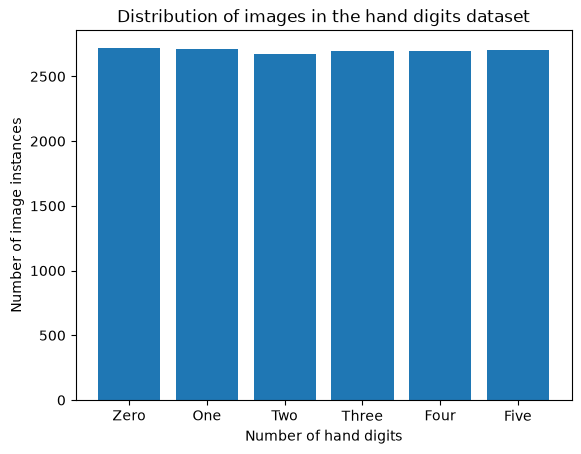

In [6]:
classList = ["Zero", "One", "Two", "Three", "Four", "Five"]
classCount = [0,0,0,0,0,0] # The number of each in the dataset

for img in digits_train:

    stringPath = str(img)
    digit_class = int(stringPath[-6]) # "[...]5R.png" returns 5, I.E the image is of 5 digits

    classCount[digit_class] +=1

plt.bar(classList, classCount)
plt.title("Distribution of images in the hand digits dataset")
plt.xlabel("Number of hand digits")
plt.ylabel("Number of image instances")


